### Coalition Truncation (`k_max`) — Exact Shapley with Fewer Subsets

The standard exhaustive MC Shapley method evaluates **all $2^d - 1$
non-empty subsets** — exponential in the number of inputs.  For $d=10$
this means 1,023 subsets; for $d=15$ it's 32,767.

However, many models — especially those built from **RS-HDMR surrogates** —
have **bounded interaction order**.  A model with `polys=[10, 5]` contains
only first-order (main effects) and second-order (pairwise) interactions.
Coalitions larger than 2 contribute nothing beyond what their sub-coalitions
already capture.

The **`k_max` parameter** exploits this:
- Limits coalition evaluation to subsets of size $\leq k_{\max}$
- Is **exact** when the model truly has no interactions above order $k_{\max}$
- Reduces subset count from $O(2^d)$ to $O(d^{k_{\max}})$

This notebook demonstrates:
1. Auto-detection from the RS-HDMR surrogate's `polys` parameter
2. Explicit `k_max` control
3. Accuracy comparison: full vs truncated
4. Computational savings

In [1]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.stats import qmc

from shapleyx import rshdmr
from shapleyx.utilities.mc_shapley import (
    GaussianCopulaUniform,
    MCShapley,
    coalitions_up_to_k,
)

from importlib.metadata import version
print(f"ShapleyX v{version('shapleyx')}")

ShapleyX v0.5.1


---
### Test Case: Owen Product Function ($d=6$)

We use the Owen product function [1] which has known interaction structure.
With $\tau = (1, 1, 0.5, 0.5, 0.25, 0.25)$, significant interactions exist
up to 4th order — making it a good stress test for the truncation.

We train an RS-HDMR surrogate with `polys=[8, 6, 4]` — up to 3rd-order
interactions — to see how `k_max=3` compares to the full $2^6-1=63$ subsets.

---
[1] Owen, A. B. (2013). "Better Estimation of Small Sobol' Sensitivity
Indices." *ACM TOMACS*, 23(2), 1–17.

In [2]:
def owen_product(m, d, tau, mu):
    """Generate samples from the Owen product function."""
    sampler = qmc.Sobol(d, scramble=True, seed=123)
    X = sampler.random_base2(m)
    Y = np.ones(2**m)
    for dim in range(d):
        g = np.sqrt(12) * (X[:, dim] - 0.5)
        Y *= (mu[dim] + tau[dim] * g)
    cols = [f'X{i+1}' for i in range(d)]
    return pd.DataFrame(np.column_stack([X, Y]), columns=cols + ['Y'])


d = 6
tau = [1.0, 1.0, 0.5, 0.5, 0.25, 0.25]
mu  = [1.0] * d

df = owen_product(m=9, d=d, tau=tau, mu=mu)
print(f"{len(df)} training samples")

512 training samples


Found a DataFrame

Transforming data to unit hypercube

Feature: X1, Min Value: 0.0001, Max Value: 0.9984
Feature: X2, Min Value: 0.0014, Max Value: 0.9985
Feature: X3, Min Value: 0.0017, Max Value: 0.9983
Feature: X4, Min Value: 0.0013, Max Value: 0.9995
Feature: X5, Min Value: 0.0001, Max Value: 0.9997
Feature: X6, Min Value: 0.0018, Max Value: 0.9999

Building basis functions

Basis functions of 1 order : 48
Basis functions of 2 order : 540
Basis functions of 3 order : 1280
Basis functions of 4 order : 3840
Total basis functions in basis set : 5708
Total number of features in basis set is 5708

Running regression analysis

running ARD
Fit Execution Time : 4.064507
--
 
 Model complete 
 

RS-HDMR model performance statistics

variance of data        : 6.410
sum of coefficients^2   : 6.008
variance ratio          : 0.937
mae error on test set   : 0.025
mse error on test set   : 0.001
explained variance score: 1.000
slope     :  0.9997921329515281
r value   :  0.9999172697875873
r^2  

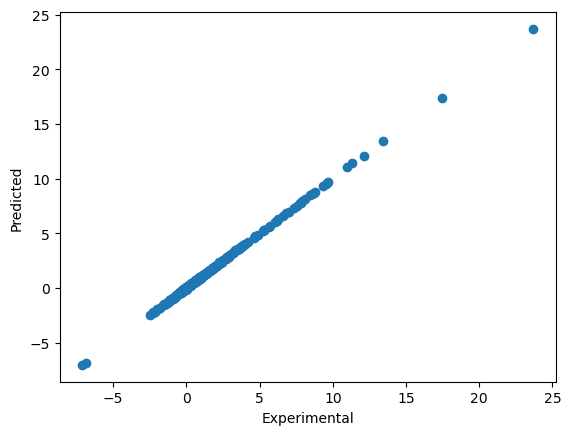


Running bootstrap resampling 1000 samples for 95.0% CI

 |████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0% 

Completed bootstrap resampling


                  Completed all analysis
                 ------------------------

The first duty of a human being is to assume the right
functional relationship to society, more briefly, to find
your real job, and do it.  Charlotte Perkins Gilman


Interaction order from polys: 4 → k_max=4


In [3]:
# Train RS-HDMR surrogate — polys=[8,6,4] has 4th-order interactions
model = rshdmr(
    df,
    polys=[8, 6, 4, 4],
    n_iter=100,
    method='ard_cv',
    cv_tol=0.005,
)
sob, shap, total = model.run_all()
print(f"\nInteraction order from polys: {len(model.polys)} → k_max={len(model.polys)}")

---
### Subset Reduction

The `coalitions_up_to_k` helper shows exactly which subsets are evaluated.

In [4]:
print("Subset counts for d = 6:")
print(f"  Full enumeration (k_max=None): {len(coalitions_up_to_k(d, None))} subsets")
for kmax in [1, 2, 3, 4, 5]:
    n = len(coalitions_up_to_k(d, kmax))
    pct = 100 * n / len(coalitions_up_to_k(d, None))
    print(f"  k_max={kmax}: {n:3d} subsets ({pct:5.1f}% of full)")

Subset counts for d = 6:
  Full enumeration (k_max=None): 63 subsets
  k_max=1:   7 subsets ( 11.1% of full)
  k_max=2:  22 subsets ( 34.9% of full)
  k_max=3:  42 subsets ( 66.7% of full)
  k_max=4:  57 subsets ( 90.5% of full)
  k_max=5:  63 subsets (100.0% of full)


---
### Auto-Detection: `k_max` from the Surrogate Model

`model.get_mc_shapley()` auto-detects `k_max = len(polys) = 3`.
For this surrogate, the result is **exact** — the expansion has no
terms above 3rd order.

In [21]:
# Auto-detected k_max=3 (from polys=[8,6,4])
t0 = time.time()
mc_auto = model.get_mc_shapley(N=3000, method='exhaustive', B=100, random_state=42, progress=True)
t_auto = time.time() - t0

# Full enumeration (k_max=None)
t0 = time.time()
mc_full = model.get_mc_shapley(N=3000, method='exhaustive', B=100,
                              k_max=5, random_state=42, progress=True)
t_full = time.time() - t0

print(f"Auto-detected (k_max=3): {t_auto:.1f}s")
print(f"Full enumeration:         {t_full:.1f}s")
print(f"Speedup: {t_full/t_auto:.1f}x")

MC Shapley: 100%|██████████| 375000/375000 [00:01<00:00, 240642.40evals/s]


Auto-detected (k_max=3): 2.3s
Full enumeration:         2.3s
Speedup: 1.0x


In [20]:
# Compare results
comparison = pd.DataFrame({
    'Variable': mc_full['variable'],
    'Full (63 subsets)': mc_full['effect'].round(4),
    'k_max=3 (42 subsets, approximate)': mc_auto['effect'].round(4),
    'Abs. Diff': np.abs(mc_full['effect'] - mc_auto['effect']).round(4),
})
comparison

,Variable,Full (63 subsets),"k_max=3 (42 subsets, approximate)",Abs. Diff
0,X1,0.3801,0.3801,0.0
1,X2,0.3670,0.3670,0.0
2,X3,0.1054,0.1054,0.0
3,X4,0.1079,0.1079,0.0
4,X5,0.0261,0.0261,0.0
5,X6,0.0135,0.0135,0.0


In [15]:
shap

,label,effect,scaled effect,lower,upper,std
0,X1,0.347349,0.347407,0.346010,0.348751,0.000700
1,X2,0.348510,0.348567,0.347016,0.349998,0.000755
2,X3,0.119203,0.119223,0.118366,0.120097,0.000437
3,X4,0.118444,0.118464,0.117293,0.119490,0.000531
4,X5,0.032948,0.032954,0.032472,0.033408,0.000241
5,X6,0.033380,0.033386,0.032816,0.033878,0.000277


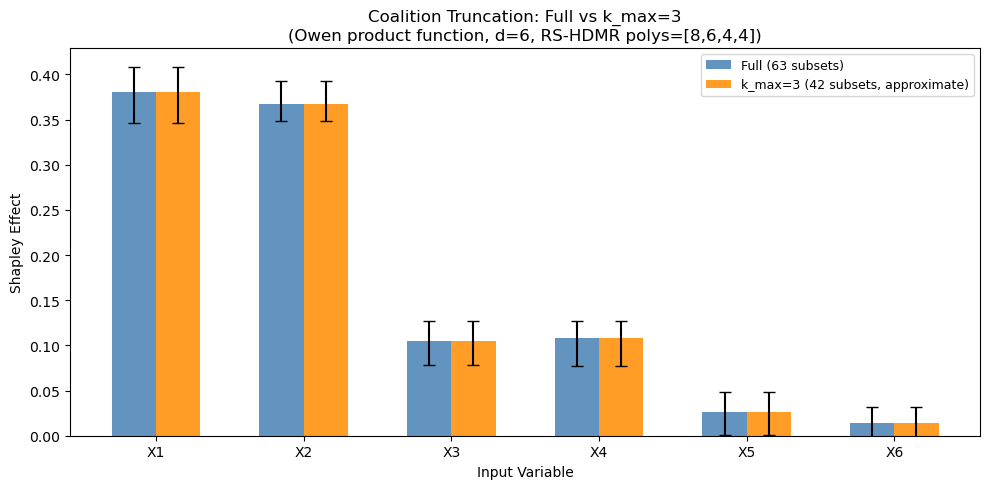

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(d)
w = 0.3

ax.bar(x - w/2, mc_full['effect'], w,
       yerr=[mc_full['effect'] - mc_full['lower'],
             mc_full['upper'] - mc_full['effect']],
       capsize=4, color='steelblue', alpha=0.85,
       label='Full (63 subsets)')
ax.bar(x + w/2, mc_auto['effect'], w,
       yerr=[mc_auto['effect'] - mc_auto['lower'],
             mc_auto['upper'] - mc_auto['effect']],
       capsize=4, color='darkorange', alpha=0.85,
       label='k_max=3 (42 subsets, approximate)')

ax.set_xlabel('Input Variable')
ax.set_ylabel('Shapley Effect')
ax.set_title('Coalition Truncation: Full vs k_max=3\n(Owen product function, d=6, RS-HDMR polys=[8,6,4,4])')
ax.set_xticks(x)
ax.set_xticklabels(mc_full['variable'])
ax.legend(fontsize=9)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

---
### Explicit `k_max` Control

You can override the auto-detected value (`k_max=4` from
polys=[8,6,4,4]) — useful when you know the true interaction
order differs from the surrogate's expansion order,
or when you want to use `k_max` as a controlled approximation.
true interaction order differs from the surrogate's expansion order,
or when you want to use `k_max` as a controlled approximation.

In [17]:
# Compare different k_max values
results = {}
for kmax in [1, 2, 3, None]:
    label = f'k_max={kmax}' if kmax else 'Full'
    mc = model.get_mc_shapley(N=2000, method='exhaustive',
                             k_max=kmax, random_state=42)
    results[label] = mc['effect'].values

comparison_df = pd.DataFrame({
    'Variable': mc_full['variable'],
    'k_max=1 (1st order)': results['k_max=1'].round(4),
    'k_max=2 (pairwise)': results['k_max=2'].round(4),
    'k_max=3 (3rd, approx)': results['k_max=3'].round(4),
    'Full (all orders)': results['Full'].round(4),
})
comparison_df

,Variable,k_max=1 (1st order),k_max=2 (pairwise),"k_max=3 (3rd, approx)",Full (all orders)
0,X1,0.4688,0.4313,0.4171,0.3697
1,X2,0.2888,0.3380,0.3608,0.3410
2,X3,0.0363,0.0653,0.0821,0.1109
3,X4,0.0744,0.0658,0.0746,0.1010
4,X5,0.0331,0.0468,0.0355,0.0445
5,X6,0.0987,0.0527,0.0298,0.0330


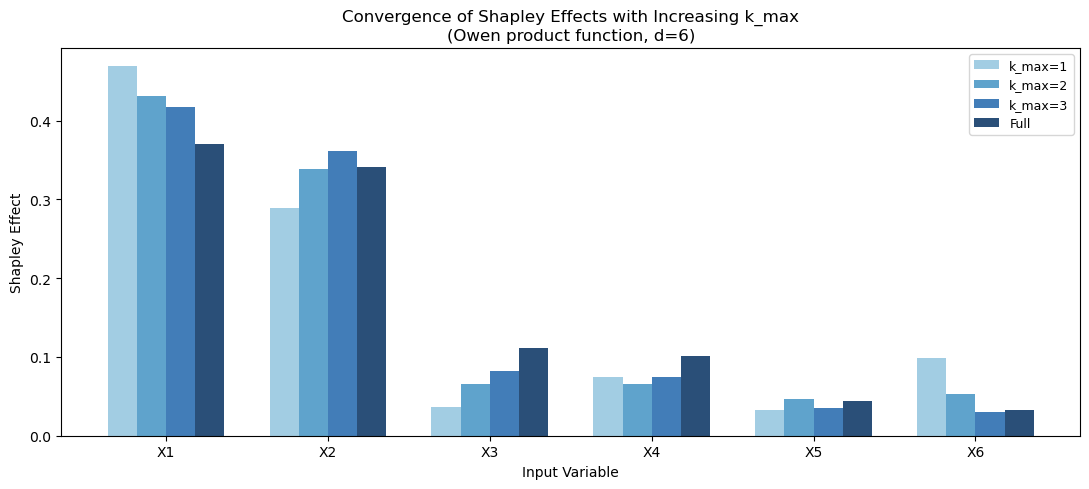

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(d)
w = 0.18
labels = ['k_max=1', 'k_max=2', 'k_max=3', 'Full']
colors = ['#92c5de', '#4393c3', '#2166ac', '#053061']

for i, (label, color) in enumerate(zip(labels, colors)):
    ax.bar(x + (i - 1.5) * w, results[label], w,
           color=color, alpha=0.85, label=label)

ax.set_xlabel('Input Variable')
ax.set_ylabel('Shapley Effect')
ax.set_title('Convergence of Shapley Effects with Increasing k_max\n(Owen product function, d=6)')
ax.set_xticks(x)
ax.set_xticklabels(mc_full['variable'])
ax.legend(fontsize=9)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

---
### Scaling: Subset Count vs Dimension

The real benefit of `k_max` appears at higher dimensions.  Below we
plot the number of subsets evaluated for different $d$ and $k_{\max}$.

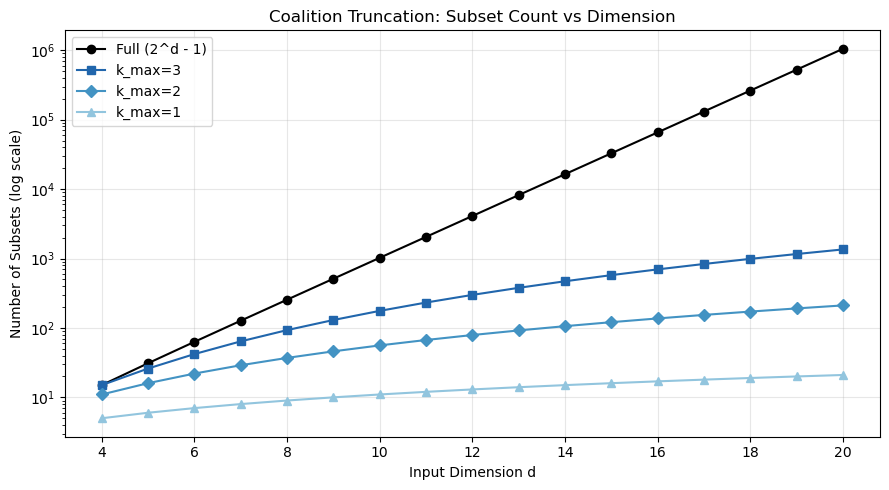

In [11]:
d_vals = np.arange(4, 21)
full_counts = [len(coalitions_up_to_k(d, None)) for d in d_vals]
k1_counts = [len(coalitions_up_to_k(d, 1)) for d in d_vals]
k2_counts = [len(coalitions_up_to_k(d, 2)) for d in d_vals]
k3_counts = [len(coalitions_up_to_k(d, 3)) for d in d_vals]

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(d_vals, full_counts, 'o-', color='black', label='Full (2^d - 1)')
ax.semilogy(d_vals, k3_counts, 's-', color='#2166ac', label='k_max=3')
ax.semilogy(d_vals, k2_counts, 'D-', color='#4393c3', label='k_max=2')
ax.semilogy(d_vals, k1_counts, '^-', color='#92c5de', label='k_max=1')

ax.set_xlabel('Input Dimension d')
ax.set_ylabel('Number of Subsets (log scale)')
ax.set_title('Coalition Truncation: Subset Count vs Dimension')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
### Key Takeaways

1. **`k_max` is auto-detected** — `model.get_mc_shapley()` sets it from
   `len(polys)`, making it exact for the surrogate model.  No manual tuning
   required.
2. **Exact when interactions are bounded** — if the model truly has no
   interactions above order $k$, `k_max=k` gives the same result as full
   enumeration (within Monte Carlo error).
3. **Dramatic computational savings** — at $d=10$ with $k_{\max}=2$,
   56 subsets vs 1,023 (18× reduction); at $d=15$, 121 vs 32,767 (270×).
4. **Controlled approximation** — even when the model has interactions
   above $k_{\max}$, the results converge rapidly as $k_{\max}$ increases.
5. **Sobol indices** — first-order $S_i$ are always available; total-order
   $T_i$ require $k_{\max} \geq d-1$ (complement sets are needed).

In [12]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Sun, 03 May 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.13.0

matplotlib: 3.10.8
numpy     : 2.3.5
pandas    : 2.3.3
scipy     : 1.17.1
shapleyx  : 0.5.1

Watermark: 2.6.0

